In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv


In [2]:
df= pd.read_csv("/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv", encoding="latin-1" )

In [3]:
COLUMNS = ['target', 'id', 'date', 'flag', 'user', 'text']

df.columns= COLUMNS

In [4]:
df.head()

,target,id,date,flag,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


# Importing Libraries

In [5]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
 
import nltk
from nltk.corpus import stopwords

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
 

Using device: cuda


##  Map labels: 0 → 0 (negative), 4 → 1 (positive)

In [9]:

df['label'] = df['target'].map({0: 0, 4: 1})

In [10]:
print(df.shape)
print(df['label'].value_counts())
print(df[['text', 'label']].head())

(1599999, 7)
label
1    800000
0    799999
Name: count, dtype: int64
                                                text  label
0  is upset that he can't update his Facebook by ...      0
1  @Kenichan I dived many times for the ball. Man...      0
2    my whole body feels itchy and like its on fire       0
3  @nationwideclass no, it's not behaving at all....      0
4                      @Kwesidei not the whole crew       0


# Cleaning Text

In [11]:
STOP_WORDS = set(stopwords.words('english'))
 
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)        # remove URLs
    text = re.sub(r'@\w+', '', text)                   # remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)              # strip # from hashtags
    text = re.sub(r'[^a-z\s]', '', text)               # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return tokens                                       # return list of tokens
 
df['tokens'] = df['text'].apply(clean_tweet)
print(df['tokens'].head())

0    [upset, cant, update, facebook, texting, might...
1    [dived, many, times, ball, managed, save, rest...
2              [whole, body, feels, itchy, like, fire]
3                       [behaving, im, mad, cant, see]
4                                        [whole, crew]
Name: tokens, dtype: object


In [12]:
MIN_FREQ = 5          # ignore rare words
MAX_VOCAB = 30000     # cap vocabulary size
 
all_tokens = [tok for tokens in df['tokens'] for tok in tokens]
freq = Counter(all_tokens)
 
# Special tokens
PAD_TOKEN = '<PAD>'   # index 0
UNK_TOKEN = '<UNK>'   # index 1
 
vocab_words = [w for w, c in freq.most_common(MAX_VOCAB) if c >= MIN_FREQ]
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
word2idx.update({w: i+2 for i, w in enumerate(vocab_words)})
idx2word = {v: k for k, v in word2idx.items()}
 
VOCAB_SIZE = len(word2idx)
print(f"Vocabulary size: {VOCAB_SIZE}")
 
def encode(tokens, max_len=50):
    """Convert token list → fixed-length integer tensor (truncate)."""
    ids = [word2idx.get(t, 1) for t in tokens[:max_len]]
    # Pad if shorter than max_len
    ids += [0] * (max_len - len(ids))
    return ids
 
MAX_LEN = 50
df['encoded'] = df['tokens'].apply(lambda t: encode(t, MAX_LEN))

Vocabulary size: 30002


# PyTorch Dataset & DataLoader

In [13]:
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.X = torch.tensor(encodings, dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.float)
 
    def __len__(self):
        return len(self.y)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
 

## Train/Val/Test split

In [14]:
X = df['encoded'].tolist()
y = df['label'].tolist()
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

In [15]:
BATCH_SIZE = 256
 
train_loader = DataLoader(TweetDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TweetDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(TweetDataset(X_test,  y_test),  batch_size=BATCH_SIZE)
 
print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
 

Train: 1,295,999  Val: 144,000  Test: 160,000


# LSTM Model

In [16]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
 
        # Embedding layer: converts token IDs → dense vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
 
        # Bidirectional LSTM: reads tweet left-to-right AND right-to-left
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
 
        self.dropout = nn.Dropout(dropout)
 
        # Classifier head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)          
        )

    def forward(self, x):
        
        embedded = self.dropout(self.embedding(x))      
        out, (hidden, _) = self.lstm(embedded)           
 
        # Concatenate last hidden state from both directions
        hidden_fwd = hidden[-2]   # forward final hidden
        hidden_bwd = hidden[-1]   # backward final hidden
        combined = torch.cat([hidden_fwd, hidden_bwd], dim=1)  
 
        logits = self.fc(self.dropout(combined))         
        return logits.squeeze(1)                         
 

In [17]:
EMBED_DIM   = 128
HIDDEN_DIM  = 256
NUM_LAYERS  = 2
DROPOUT     = 0.4
LR          = 1e-3
EPOCHS      = 5
 
model = SentimentLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(DEVICE)
print(model)
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
 

SentimentLSTM(
  (embedding): Embedding(30002, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=512, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total params: 6,240,641


# Training Loop

## Loss func. and Optimizer

In [18]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)
 

In [19]:
def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        preds = (torch.sigmoid(logits) >= 0.5).long()
        correct += (preds == y_batch.long()).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)
 
def evaluate(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds = (torch.sigmoid(logits) >= 0.5).long()
            correct += (preds == y_batch.long()).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)
 

## Loop

In [20]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
 
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc = evaluate(model, val_loader)
    scheduler.step(vl_loss)
 
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
 
    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")
 
    # Save best model
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), 'best_lstm_sentiment.pt')
        print("  → Best model saved")

Epoch 1/5 | Train Loss: 0.5078 Acc: 0.7490 | Val Loss: 0.4506 Acc: 0.7865
  → Best model saved
Epoch 2/5 | Train Loss: 0.4617 Acc: 0.7818 | Val Loss: 0.4376 Acc: 0.7948
  → Best model saved
Epoch 3/5 | Train Loss: 0.4468 Acc: 0.7911 | Val Loss: 0.4330 Acc: 0.7988
  → Best model saved
Epoch 4/5 | Train Loss: 0.4372 Acc: 0.7967 | Val Loss: 0.4298 Acc: 0.8013
  → Best model saved
Epoch 5/5 | Train Loss: 0.4310 Acc: 0.8006 | Val Loss: 0.4283 Acc: 0.8020
  → Best model saved


# Evaluate on Test Set

In [21]:
model.load_state_dict(torch.load('best_lstm_sentiment.pt'))
model.eval()
 
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch)
        preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy().astype(int))
 
print("\n Test Results")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
 


 Test Results
              precision    recall  f1-score   support

    Negative       0.80      0.80      0.80     80000
    Positive       0.80      0.80      0.80     80000

    accuracy                           0.80    160000
   macro avg       0.80      0.80      0.80    160000
weighted avg       0.80      0.80      0.80    160000

Accuracy: 0.8009


# Visualize Training

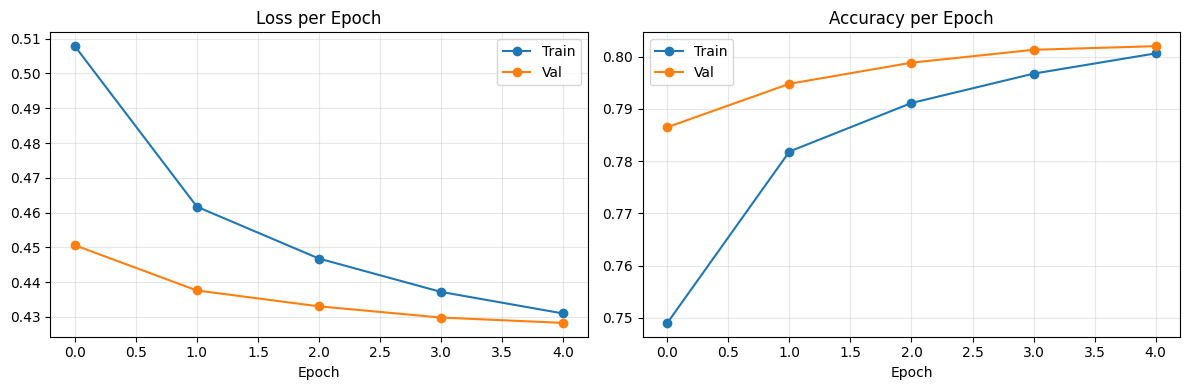

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# For Loss per epoch
axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss per Epoch'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

# For Accuracy Per epoch
axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'],   label='Val',   marker='o')
axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Confusion Matrix

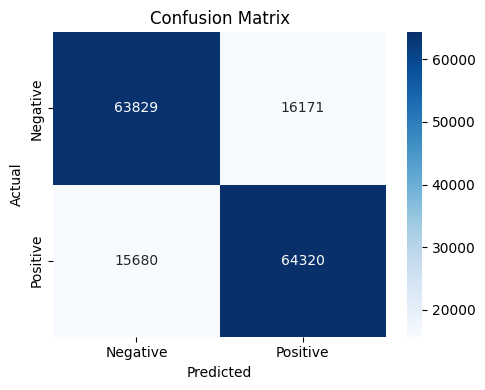

In [23]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150); plt.show()

# Prediction on new tweet

In [24]:
def predict(text, model, word2idx, max_len=50, threshold=0.5):
    model.eval()
    tokens = clean_tweet(text)
    encoded = encode(tokens, max_len)
    x = torch.tensor([encoded], dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()
    label = 'Positive' if prob >= threshold else 'Negative'
    return label, round(prob, 4)

In [25]:

examples = [
    "I love this product, it's amazing!",
    "This is the worst experience I've ever had.",
    "The weather today is just okay.",
    "So happy to see my friends again!",
    "I can't believe how terrible this is..."
]
 
print("\n Predictions")
for tweet in examples:
    label, prob = predict(tweet, model, word2idx)
    print(f"  '{tweet}'")
    print(f"   → {label}  (confidence: {prob})\n")
 


 Predictions
  'I love this product, it's amazing!'
   → Positive  (confidence: 0.992)

  'This is the worst experience I've ever had.'
   → Negative  (confidence: 0.0542)

  'The weather today is just okay.'
   → Negative  (confidence: 0.3669)

  'So happy to see my friends again!'
   → Positive  (confidence: 0.9555)

  'I can't believe how terrible this is...'
   → Negative  (confidence: 0.0037)

